In [1]:
import torch

from perspective import Retina, Monitor, Perspective

from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout

import matplotlib.pyplot as plt

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = ['/srv/user/polina/sensorium/sensorium/notebooks/data/static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip', ]

dataset_fn = 'sensorium.datasets.static_loaders'
dataset_config = {'paths': filenames,
                 'normalize': True,
                 'include_behavior': False,
                 'include_eye_position': True,
                 'batch_size': 64,
                 'scale':0.25,
                 }

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
grid_mean_predictor = {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True
}

model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 0.0076,
  'hidden_kern': 7,
  'hidden_channels': 64,
  'depth_separable': True,
  'grid_mean_predictor': {'type': 'cortex',
   'input_dimensions': 2,
   'hidden_layers': 1,
   'hidden_features': 30,
   'final_tanh': True},
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': False,
}

perspective = Perspective(Retina(mlp_features=[8, 8, 8], device=device), Monitor(device=device)).to(device)
model_config['perspective'] = perspective

In [4]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [5]:
trainer_fn = "sensorium.training.standard_trainer"

trainer_config = {'max_iter': 200,
                 'verbose': True,
                 'lr_decay_steps': 4,
                 'avg_loss': False,
                 'lr_init': 0.009,
                 'track_training': True,
                 }

trainer_config['device'] = 'cuda:7'

trainer = get_trainer(trainer_fn=trainer_fn, 
                     trainer_config=trainer_config)

In [6]:
validation_score, trainer_output, state_dict = trainer(model, dataloaders, seed=random_seed)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")


correlation -0.0072536594
poisson_loss 4192953.5


Epoch 1: 100%|██████████| 70/70 [00:31<00:00,  2.25it/s]


correlation 0.0595203
poisson_loss 2716093.5


Epoch 2: 100%|██████████| 70/70 [00:26<00:00,  2.63it/s]


...

Epoch 146: 100%|██████████| 70/70 [00:26<00:00,  2.63it/s]


correlation 0.30379108
poisson_loss 2359826.5


Epoch 147: 100%|██████████| 70/70 [00:26<00:00,  2.64it/s]


correlation 0.30424505
poisson_loss 2359611.5


Epoch 148: 100%|██████████| 70/70 [00:26<00:00,  2.62it/s]


In [7]:
validation_score

np.float32(0.31687516)

In [10]:
list(perspective.parameters())

[Parameter containing:
 tensor([[ 0.2861, -0.4592],
         [ 0.5964,  0.4528],
         [ 0.3017,  0.1033],
         [ 0.1334,  0.0866],
         [-0.4389,  0.0145],
         [-0.2142,  0.2262],
         [ 0.0861,  0.0796],
         [-0.6559, -0.5220]], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([ 0.4754, -0.6962,  0.2863, -0.7620,  0.4354,  0.6201, -0.5837,  0.6863],
        device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[-0.2403, -0.3398,  0.3911, -0.0271,  0.1403,  0.4360,  0.2147, -0.0455],
         [-0.4857, -0.0370,  0.0183,  0.0043, -0.1999, -0.0852,  0.1506, -0.2522],
         [ 0.1384, -0.2784, -0.2742,  0.1610, -0.3576, -0.0381, -0.0692, -0.2650],
         [-0.3766,  0.6936,  0.0361,  0.3977, -0.3306,  0.1600,  0.2496, -0.2412],
         [-0.1290, -0.6427,  0.3829,  0.0687,  0.1904, -0.1123, -0.0472,  0.4218],
         [ 0.4987,  0.4338,  0.2790, -0.0937, -0.0951,  0.0930,  0.0263, -0.0773],
         [-0.6830, -0.2985,  0.019

tensor(0.1411)
tensor(0.6736)
tensor(-0.0819)
tensor(-1.2878)
tensor(0.2231)
tensor(-0.1468)
tensor(0.5510)
tensor(-1.5668)
tensor(1.7822)
tensor(-0.3900)


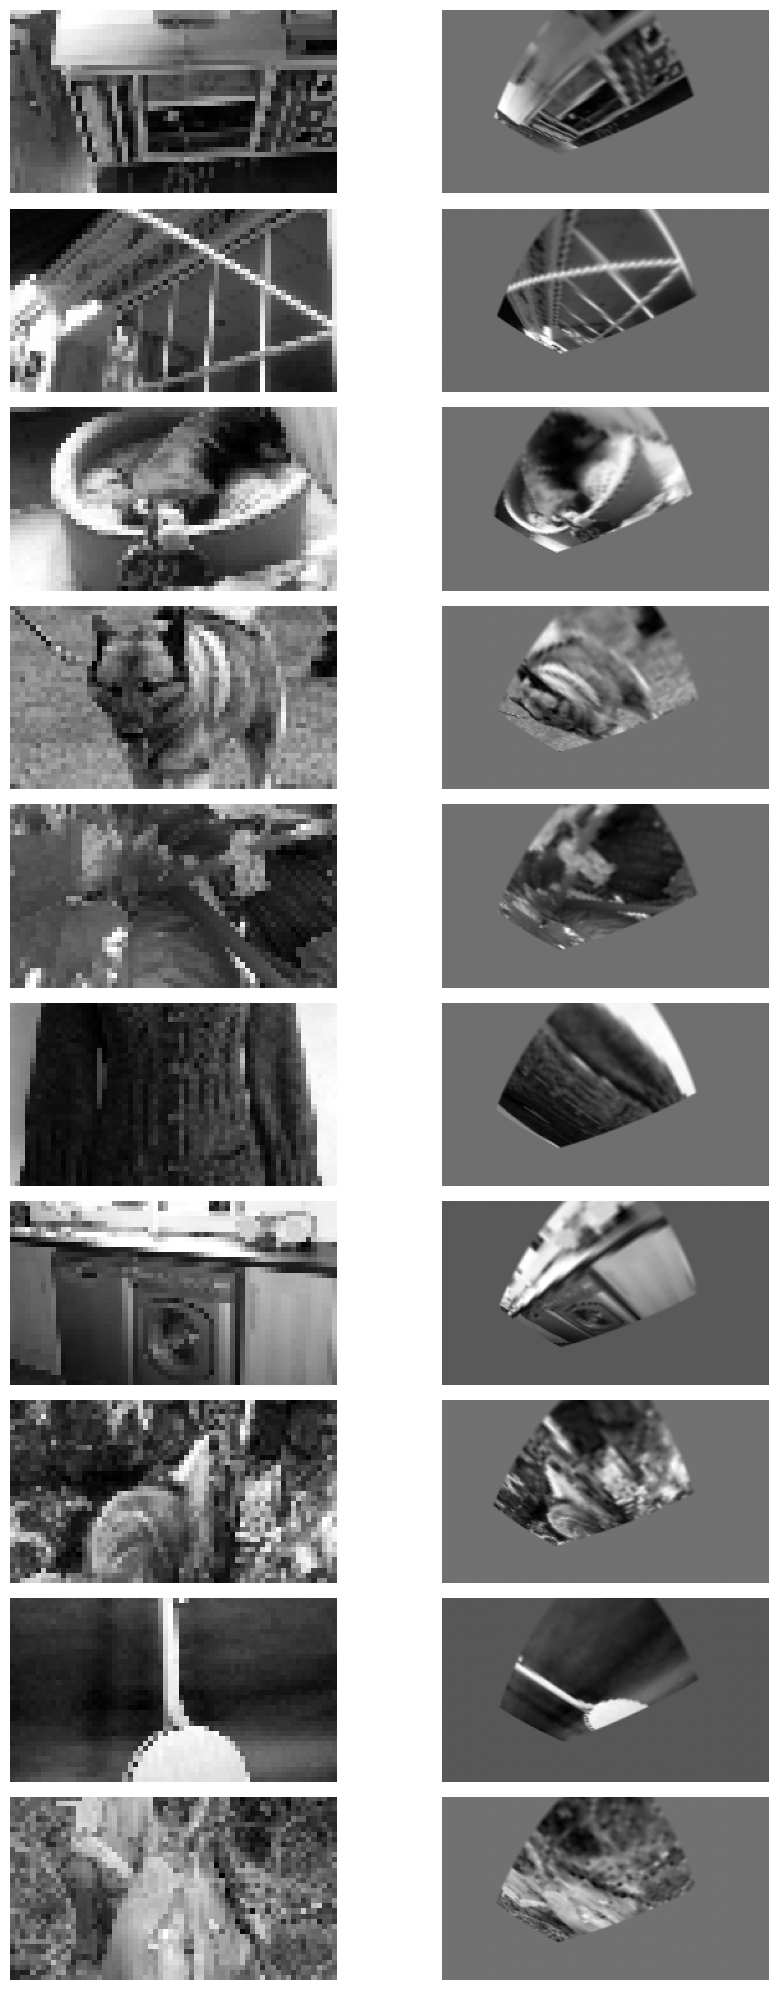

In [11]:
data_key = "27204-5-13"
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

for i in range(10):
    ax[i, 0].imshow(batch.images[i, 0].detach().cpu(), cmap='gray')
    ax[i, 0].axis('off')
    print(batch.pupil_center[i, 0].detach().cpu())
    ax[i, 1].imshow(perspective(batch.images, batch.pupil_center)[i, 0].detach().cpu(), cmap='gray')
    ax[i, 1].axis('off')

plt.tight_layout()

seed 41 results:  
    Parameter containing:  
    tensor([-0.2717,  0.1146,  1.2536], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([ 0.5564,  0.5958, -0.2947], device='cuda:7', requires_grad=True)  

seed 40 results:  
    Parameter containing:  
    tensor([-0.4187,  0.2635,  1.1136], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([ 0.7092,  0.4121, -0.6947], device='cuda:7', requires_grad=True)  

seed 39 results:  
    Parameter containing:  
    tensor([-0.4425, -0.2122,  1.1337], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([-0.2125,  0.5381,  0.8054], device='cuda:7', requires_grad=True)  